# Tabular Model Tuning + Calibration

This notebook tunes and calibrates the tabular default-risk model (Model A's
feature set) with Optuna and isotonic regression. It ends by freezing the
chosen hyperparameters to `config/tabular_best_params.json`, which
`scripts/train_final.py` reads to deterministically reproduce the exact same
artifact with no search involved.

**This does not touch `models/model_a.pkl`** — the original baseline is left
alone. The output here is a new, separate artifact:
`models/model_a_tuned_calibrated.pkl`.

## Split discipline — the leakage guard

`data/interim/split_indices.pkl` holds the TRAIN/TEST partition Model A was
scored on. **The TEST indices are pristine**: they are not touched anywhere in
this notebook except the single, last code cell, run once, for the final
report.

Everything below — tuning, early stopping, calibration — happens on a
three-way split carved **only out of the TRAIN indices**, stratified, seed 42:

- `train_inner` (~70% of train) — fits the model.
- `val` (~15% of train) — early stopping + the Optuna objective.
- `calib` (~15% of train) — fits the isotonic calibrator, unseen by the model fit.

Categorical columns are cast to `category` dtype **once**, on the full
`feasibility_frame.pkl`, exactly as Model A was built — never re-cast
independently per split. XGBoost's categorical splits are code-based, so
re-deriving categories from a subset could silently assign different codes to
the same string and corrupt inference.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "font.size": 11,
})

ROOT = Path("..").resolve()
SEED = 42
EARLY_STOPPING_ROUNDS = 30
BAR_COLOR = "#3b6ea5"
ACCENT_COLOR = "#c0453a"

RAW_TABULAR_COLS = [
    "loan_amnt", "term", "int_rate", "grade", "sub_grade",
    "annual_inc", "dti", "emp_length", "home_ownership",
    "verification_status", "fico_range_low", "fico_range_high", "purpose",
]
CATEGORICAL_COLS = ["grade", "sub_grade", "home_ownership", "verification_status", "purpose"]
EMP_LENGTH_MAP = {
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
    "10+ years": 10,
}


def build_tabular_features(df, cols=RAW_TABULAR_COLS):
    X = df[cols].copy()
    X["term"] = X["term"].astype(str).str.extract(r"(\d+)").astype("float32")
    X["emp_length"] = X["emp_length"].map(EMP_LENGTH_MAP).astype("float32")
    for c in CATEGORICAL_COLS:
        X[c] = X[c].astype("category")
    return X

C:\Users\karth\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pickle

frame = pd.read_pickle(ROOT / "data" / "interim" / "feasibility_frame.pkl")
with open(ROOT / "data" / "interim" / "split_indices.pkl", "rb") as f:
    split = pickle.load(f)

train_idx_full = split["train_idx"]   # the 80% TRAIN partition. TEST stays untouched below.
# NOTE: split["test_idx"] is intentionally never read into a variable here.
# test_idx / X_test / y_test are first defined in the guardrail cell at the
# very end of this notebook -- referencing them earlier would raise NameError.

y = frame["default"].astype(int)

# Categories derived ONCE from the full frame -- never re-cast per split.
X_full = build_tabular_features(frame)
FEATURE_ORDER = list(X_full.columns)
CATEGORIES = {c: X_full[c].cat.categories for c in CATEGORICAL_COLS}

# Stratified 3-way split, carved only out of TRAIN indices.
train_inner_idx, temp_idx = train_test_split(
    train_idx_full, test_size=0.30, stratify=y.loc[train_idx_full], random_state=SEED
)
val_idx, calib_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y.loc[temp_idx], random_state=SEED
)

assert set(train_inner_idx).isdisjoint(val_idx)
assert set(train_inner_idx).isdisjoint(calib_idx)
assert set(val_idx).isdisjoint(calib_idx)
assert set(train_inner_idx) | set(val_idx) | set(calib_idx) == set(train_idx_full)

X_train_inner, y_train_inner = X_full.loc[train_inner_idx], y.loc[train_inner_idx]
X_val, y_val = X_full.loc[val_idx], y.loc[val_idx]
X_calib, y_calib = X_full.loc[calib_idx], y.loc[calib_idx]

print(f"train_inner: {len(train_inner_idx):,} rows ({100*len(train_inner_idx)/len(train_idx_full):.1f}% of train)")
print(f"val:         {len(val_idx):,} rows ({100*len(val_idx)/len(train_idx_full):.1f}% of train)")
print(f"calib:       {len(calib_idx):,} rows ({100*len(calib_idx)/len(train_idx_full):.1f}% of train)")
print(f"(test set: {len(split['test_idx']):,} rows -- indices held, NOT loaded as features yet)")

train_inner: 60,522 rows (70.0% of train)
val:         12,969 rows (15.0% of train)
calib:       12,969 rows (15.0% of train)
(test set: 21,616 rows -- indices held, NOT loaded as features yet)


## Tuning — Optuna over `train_inner` / `val` only

40 trials, TPE sampler, maximizing validation PR-AUC
(`average_precision_score`). Each trial fits on `train_inner` with early
stopping on `val` (30 rounds); `n_estimators` is sampled as an upper cap and
the actual tree count is whatever early stopping settles on.

In [3]:
def make_xgb_params(trial_params):
    return dict(
        **trial_params,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        enable_categorical=True,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        random_state=SEED,
        n_jobs=-1,
    )


def objective(trial):
    trial_params = {
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
    }
    model = XGBClassifier(**make_xgb_params(trial_params))
    model.fit(X_train_inner, y_train_inner, eval_set=[(X_val, y_val)], verbose=False)
    proba_val = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, proba_val)


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=40, show_progress_bar=False)

print(f"Best val PR-AUC: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best val PR-AUC: 0.2940
Best params:
  max_depth: 2
  learning_rate: 0.16082866822939967
  min_child_weight: 13
  subsample: 0.9342507578839896
  colsample_bytree: 0.5617104625598865
  reg_lambda: 0.3008927197344441
  n_estimators: 427


C:\Users\karth\AppData\Local\Temp\ipykernel_3872\1935144615.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax1 = plot_optimization_history(study)


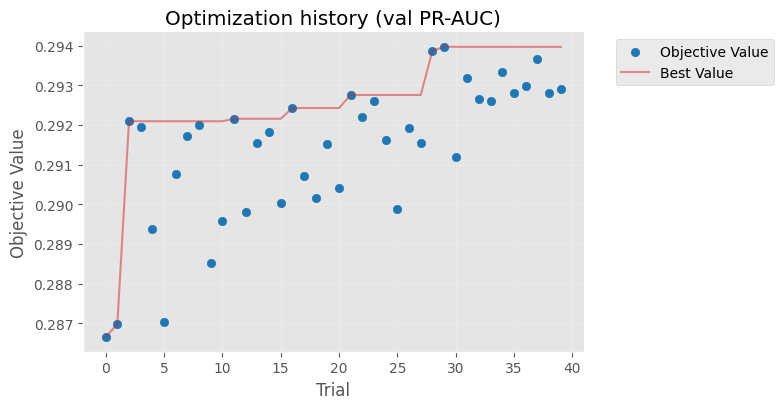

C:\Users\karth\AppData\Local\Temp\ipykernel_3872\1935144615.py:9: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax2 = plot_param_importances(study)


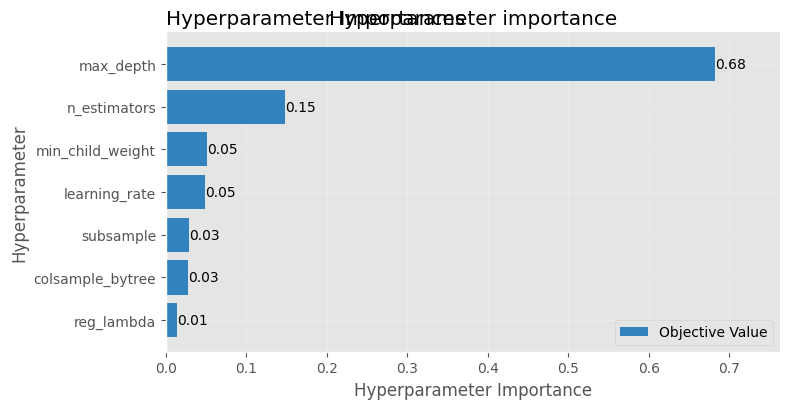

In [4]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

ax1 = plot_optimization_history(study)
ax1.set_title("Optimization history (val PR-AUC)")
ax1.figure.set_size_inches(8, 4.2)
ax1.figure.tight_layout()
plt.show()

ax2 = plot_param_importances(study)
ax2.set_title("Hyperparameter importance")
ax2.figure.set_size_inches(8, 4.2)
ax2.figure.tight_layout()
plt.show()

## Calibration — refit on `train_inner`, calibrate on `calib`

Refit the best trial's hyperparameters on `train_inner` (early stopping on
`val`, same as every trial), then fit isotonic regression mapping raw
predicted probabilities to observed frequencies, using **only the `calib`
slice** — rows the model never trained or early-stopped on.

The before/after check below runs on `calib` itself, since that's the data
the calibrator was fit to — a sanity check that isotonic did what it's
supposed to, not a held-out evaluation. The real held-out calibration numbers
come from the locked TEST set in the final section.

In [5]:
final_params = make_xgb_params(study.best_params)
final_model = XGBClassifier(**final_params)
final_model.fit(X_train_inner, y_train_inner, eval_set=[(X_val, y_val)], verbose=False)

print(f"Refit best_iteration: {final_model.best_iteration} (cap was {study.best_params['n_estimators']})")

proba_calib_raw = final_model.predict_proba(X_calib)[:, 1]

calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(proba_calib_raw, y_calib)
proba_calib_calibrated = calibrator.predict(proba_calib_raw)

Refit best_iteration: 134 (cap was 427)


Calibration slice (in-sample sanity check, NOT test):
  Brier  before: 0.1216   after: 0.1210
  ECE    before: 0.0050   after: 0.0001


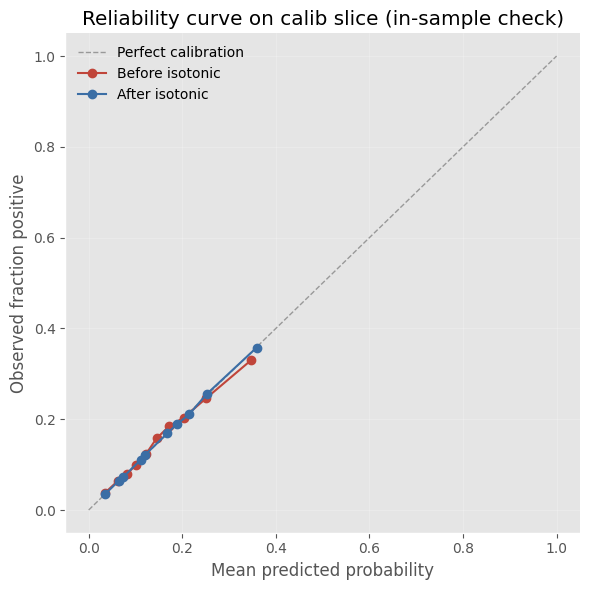

In [6]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.clip(np.digitize(y_prob, bin_edges[1:-1]), 0, n_bins - 1)
    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if not mask.any():
            continue
        ece += (mask.sum() / len(y_prob)) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece


brier_before = brier_score_loss(y_calib, proba_calib_raw)
brier_after = brier_score_loss(y_calib, proba_calib_calibrated)
ece_before = expected_calibration_error(y_calib, proba_calib_raw)
ece_after = expected_calibration_error(y_calib, proba_calib_calibrated)

print("Calibration slice (in-sample sanity check, NOT test):")
print(f"  Brier  before: {brier_before:.4f}   after: {brier_after:.4f}")
print(f"  ECE    before: {ece_before:.4f}   after: {ece_after:.4f}")

frac_pos_before, mean_pred_before = calibration_curve(y_calib, proba_calib_raw, n_bins=10, strategy="quantile")
frac_pos_after, mean_pred_after = calibration_curve(y_calib, proba_calib_calibrated, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="#999999", linewidth=1, label="Perfect calibration")
ax.plot(mean_pred_before, frac_pos_before, marker="o", color=ACCENT_COLOR, label="Before isotonic")
ax.plot(mean_pred_after, frac_pos_after, marker="o", color=BAR_COLOR, label="After isotonic")
ax.set_title("Reliability curve on calib slice (in-sample check)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction positive")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

## Freeze — write the chosen hyperparameters

`scripts/train_final.py` reads this file and rebuilds the identical model
deterministically, with no search — this is the single source of truth for
what "tuned" means going forward.

In [7]:
config = {
    "max_depth": study.best_params["max_depth"],
    "learning_rate": study.best_params["learning_rate"],
    "min_child_weight": study.best_params["min_child_weight"],
    "subsample": study.best_params["subsample"],
    "colsample_bytree": study.best_params["colsample_bytree"],
    "reg_lambda": study.best_params["reg_lambda"],
    "n_estimators": study.best_params["n_estimators"],
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
    "random_state": SEED,
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "enable_categorical": True,
    "features": FEATURE_ORDER,
    "optuna_best_val_pr_auc": study.best_value,
    "optuna_n_trials": 40,
    "refit_best_iteration": int(final_model.best_iteration),
}

config_path = ROOT / "config" / "tabular_best_params.json"
config_path.parent.mkdir(parents=True, exist_ok=True)
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Wrote {config_path}")
print(json.dumps(config, indent=2))

Wrote E:\New folder\config\tabular_best_params.json
{
  "max_depth": 2,
  "learning_rate": 0.16082866822939967,
  "min_child_weight": 13,
  "subsample": 0.9342507578839896,
  "colsample_bytree": 0.5617104625598865,
  "reg_lambda": 0.3008927197344441,
  "n_estimators": 427,
  "early_stopping_rounds": 30,
  "random_state": 42,
  "objective": "binary:logistic",
  "eval_metric": "aucpr",
  "tree_method": "hist",
  "enable_categorical": true,
  "features": [
    "loan_amnt",
    "term",
    "int_rate",
    "grade",
    "sub_grade",
    "annual_inc",
    "dti",
    "emp_length",
    "home_ownership",
    "verification_status",
    "fico_range_low",
    "fico_range_high",
    "purpose"
  ],
  "optuna_best_val_pr_auc": 0.29396738123584737,
  "optuna_n_trials": 40,
  "refit_best_iteration": 134
}


---
## ⚠️ TEST-PEEKING GUARDRAIL

**Run once; do not iterate after seeing this.** The cell below is the ONLY
place in this notebook that reads the locked TEST set. Nothing above this
point has touched it — `X_test`/`y_test` don't exist until this cell defines
them, so any earlier accidental reference would have raised a `NameError`,
not silently leaked. This cell produces the final report and nothing more: no
further tuning, selection, or calibration decisions happen after this point.

=== LOCKED TEST REPORT (read once) ===
model_a  (original): PR-AUC=0.2769  ROC-AUC=0.6912
tuned    (this run): PR-AUC=0.2803  ROC-AUC=0.6920
Delta PR-AUC (tuned - original): +0.0034

Calibration on TEST -- Brier  before=0.1213  after=0.1216
Calibration on TEST -- ECE    before=0.0029  after=0.0046


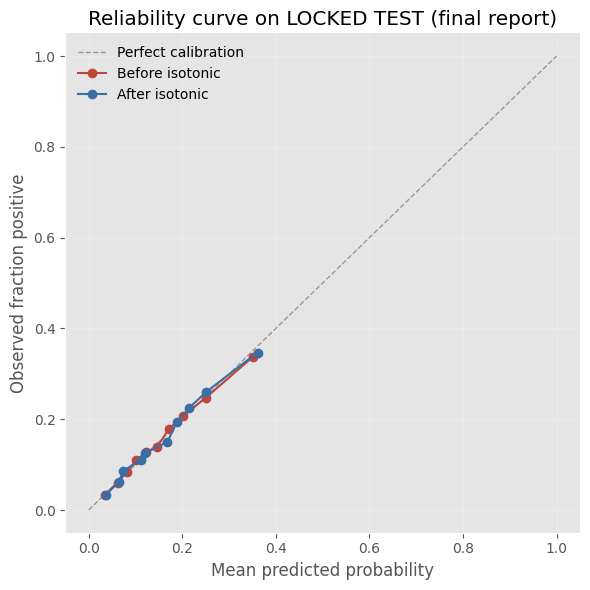


HONEST LINE: tuning + calibration moved test PR-AUC by +0.0034 vs the original Model A baseline (0.2769 -> 0.2803).


In [8]:
import pickle as _pickle

test_idx = split["test_idx"]
assert set(test_idx).isdisjoint(train_inner_idx)
assert set(test_idx).isdisjoint(val_idx)
assert set(test_idx).isdisjoint(calib_idx)

X_test, y_test = X_full.loc[test_idx], y.loc[test_idx]

# Original Model A, for comparison -- loaded read-only, never modified.
with open(ROOT / "models" / "model_a.pkl", "rb") as f:
    model_a_bundle = _pickle.load(f)
model_a = model_a_bundle["model"]

proba_test_a = model_a.predict_proba(X_test[model_a_bundle["features"]])[:, 1]
proba_test_tuned_raw = final_model.predict_proba(X_test)[:, 1]
proba_test_tuned_calibrated = calibrator.predict(proba_test_tuned_raw)

pr_auc_a = average_precision_score(y_test, proba_test_a)
roc_auc_a = roc_auc_score(y_test, proba_test_a)
pr_auc_tuned = average_precision_score(y_test, proba_test_tuned_raw)
roc_auc_tuned = roc_auc_score(y_test, proba_test_tuned_raw)

brier_test_before = brier_score_loss(y_test, proba_test_tuned_raw)
brier_test_after = brier_score_loss(y_test, proba_test_tuned_calibrated)
ece_test_before = expected_calibration_error(y_test, proba_test_tuned_raw)
ece_test_after = expected_calibration_error(y_test, proba_test_tuned_calibrated)

print("=== LOCKED TEST REPORT (read once) ===")
print(f"model_a  (original): PR-AUC={pr_auc_a:.4f}  ROC-AUC={roc_auc_a:.4f}")
print(f"tuned    (this run): PR-AUC={pr_auc_tuned:.4f}  ROC-AUC={roc_auc_tuned:.4f}")
print(f"Delta PR-AUC (tuned - original): {pr_auc_tuned - pr_auc_a:+.4f}")
print()
print(f"Calibration on TEST -- Brier  before={brier_test_before:.4f}  after={brier_test_after:.4f}")
print(f"Calibration on TEST -- ECE    before={ece_test_before:.4f}  after={ece_test_after:.4f}")

frac_pos_test_before, mean_pred_test_before = calibration_curve(
    y_test, proba_test_tuned_raw, n_bins=10, strategy="quantile"
)
frac_pos_test_after, mean_pred_test_after = calibration_curve(
    y_test, proba_test_tuned_calibrated, n_bins=10, strategy="quantile"
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="#999999", linewidth=1, label="Perfect calibration")
ax.plot(mean_pred_test_before, frac_pos_test_before, marker="o", color=ACCENT_COLOR, label="Before isotonic")
ax.plot(mean_pred_test_after, frac_pos_test_after, marker="o", color=BAR_COLOR, label="After isotonic")
ax.set_title("Reliability curve on LOCKED TEST (final report)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction positive")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

print()
print(f"HONEST LINE: tuning + calibration moved test PR-AUC by {pr_auc_tuned - pr_auc_a:+.4f} "
      f"vs the original Model A baseline ({pr_auc_a:.4f} -> {pr_auc_tuned:.4f}).")